
# Previsão de Expansão Urbana com Random Forest

- carregar imagens VIIRS `.tif`
- gerar imagens anuais
- treinar Random Forest espacial
- prever expansão urbana futura
- gerar mapas previstos


# Imports

In [133]:

import os
import glob

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor


# Constantes

In [134]:

BASE_PATH = os.getcwd()

THRESHOLD_EXPANSAO = 5


# Leitura das imagens

In [135]:

def carregar_imagem_bruta(regiao, ano, mes):
    pasta = os.path.join(
        BASE_PATH,
        "data",
        "NTL_LITORAL_SC",
        "QGIS_LITORAL",
        "RASTER",
        "NTL_LITORAL",
        f"NTL_{ano}"
    )

    padrao = os.path.join(
        pasta,
        f"*{regiao}*_{ano}_{mes}*.tif"
    )

    arquivos = glob.glob(padrao)

    if len(arquivos) == 0:
        print(f"Nenhum arquivo encontrado: {padrao}")
        return None

    caminho = arquivos[0]

    img = cv2.imread(caminho, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None

    img = np.nan_to_num(img, nan=0.0)
    img[img < 0] = 0

    if len(img.shape) == 3:
        img = img[:, :, 0]

    return img.astype(np.float32)

In [136]:

def extrair_features(img):
    """Extrai features vetorizadas para a imagem inteira.
    Retorna uma matriz (N_pixels_interior, 4) com features para pixels 1:-1,1:-1.
    Features: [pixel, mean(3x3), std(3x3), max(3x3)]."""
    img = img.astype(np.float32)

    # Média e desvio local por 3x3 (usando filtros C acelerados)
    mean = cv2.blur(img, (3, 3))
    mean_sq = cv2.blur(img * img, (3, 3))
    std = np.sqrt(np.maximum(mean_sq - mean * mean, 0))

    # Máximo local via dilatação (3x3)
    kernel = np.ones((3, 3), dtype=np.uint8)
    max_img = cv2.dilate(img, kernel)

    # Seleciona pixels interiores (evita bordas onde a vizinhança está incompleta)
    slice_idx = (slice(1, -1), slice(1, -1))

    f0 = img[slice_idx].ravel()
    f1 = mean[slice_idx].ravel()
    f2 = std[slice_idx].ravel()
    f3 = max_img[slice_idx].ravel()

    features = np.column_stack((f0, f1, f2, f3)).astype(np.float32)
    return features

# Montar composição de imagem anual

In [137]:

def montar_imagem_anual(regiao, ano):

    imagens = []

    for mes in range(1, 13):

        mes_str = str(mes).zfill(2)

        img = carregar_imagem_bruta(
            regiao,
            ano,
            mes_str
        )

        if img is not None:
            imagens.append(img)

    if len(imagens) == 0:
        return None

    ref_shape = imagens[0].shape

    imagens_ajustadas = []

    for img in imagens:

        if img.shape != ref_shape:

            img = cv2.resize(
                img,
                (ref_shape[1], ref_shape[0]),
                interpolation=cv2.INTER_LINEAR
            )

        imagens_ajustadas.append(img)

    stack = np.stack(
        imagens_ajustadas,
        axis=0
    )

    composto = np.median(
        stack,
        axis=0
    )

    return composto


# Features por pixel

In [138]:

def extrair_features_pixel(img, i, j):

    pixel = img[i, j]

    vizinhanca = img[
        i-1:i+2,
        j-1:j+2
    ]

    media_viz = np.mean(vizinhanca)
    desvio_viz = np.std(vizinhanca)
    max_viz = np.max(vizinhanca)

    return [
        pixel,
        media_viz,
        desvio_viz,
        max_viz
    ]


# Construção do dataset

In [139]:
def construir_dataset(regiao):
    X_list = []
    y_list = []

    anos = list(range(2015, 2025))

    for ano in anos[:-1]:

        print(f"Processando {ano}")

        img_atual = montar_imagem_anual(regiao, ano)
        img_futuro = montar_imagem_anual(regiao, ano + 1)

        if img_atual is None or img_futuro is None:
            continue

        # Extrai features vetorizadas para todos os pixels interiores
        features = extrair_features(img_atual)

        # Target: pixel correspondente no futuro (mesma janela interior)
        alvo = img_futuro[1:-1, 1:-1].ravel().astype(np.float32)

        X_list.append(features)
        y_list.append(alvo)

    if X_list:
        X = np.vstack(X_list).astype(np.float32)
        y = np.concatenate(y_list).astype(np.float32)
    else:
        X = np.empty((0, 4), dtype=np.float32)
        y = np.empty((0,), dtype=np.float32)

    print("Dataset criado:")
    print(X.shape)
    print(y.shape)

    return X, y

# Treinamento do Random Forest

In [140]:
def treinar_modelo(regiao):

    X,y = construir_dataset(regiao)

    modelo = RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )

    print("Treinando modelo...")

    modelo.fit(X, y)

    print("Treinamento concluído.")

    return modelo


# Previsão da expansão futura

In [141]:
def previsao(regiao):
    modelo = treinar_modelo(regiao)

    img_final = montar_imagem_anual(
        regiao,
        2025
    )

    altura, largura = img_final.shape

    pred_img = np.zeros_like(
        img_final,
        dtype=np.float32
    )

    print("Gerando previsão...")

    # Vetoriza extração de features para toda a imagem interior e prevê em batch
    features = extrair_features(img_final)

    # Prever em batches para controlar uso de memória
    batch_size = 100000
    preds_parts = []
    for start in range(0, features.shape[0], batch_size):
        end = start + batch_size
        preds_parts.append(modelo.predict(features[start:end]))

    preds = np.concatenate(preds_parts)

    # Reconstroi imagem de previsão (preenche apenas a região interior)
    h_interior = altura - 2
    w_interior = largura - 2
    pred_img[1:-1, 1:-1] = preds.reshape((h_interior, w_interior)).astype(np.float32)

    print("Previsão concluída.")

    return pred_img, img_final


# Máscara de expansão prevista

In [142]:

def gerar_expansao(regiao):
    pred_img, img_final = previsao(regiao)

    crescimento_previsto = (
        pred_img > img_final + THRESHOLD_EXPANSAO
    ).astype(np.uint8) * 255

    return pred_img, img_final, crescimento_previsto


# Visualização

In [143]:
def visualizar_expansao(pred_img, img_final, crescimento_previsto):

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.title("Imagem formada de 2025")
    plt.imshow(img_final, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Imagem prevista")
    plt.imshow(pred_img, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Expansão prevista")
    plt.imshow(crescimento_previsto, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# Salvando resultados

In [144]:
def salvar_resultados(pred_img, crescimento_previsto):

    output_dir = os.path.join(
        BASE_PATH,
        "generated_images"
    )

    os.makedirs(
        output_dir,
        exist_ok=True
    )

    pred_vis = cv2.normalize(
        pred_img,
        None,
        0,
        255,
        cv2.NORM_MINMAX,
        dtype=cv2.CV_8U
    )

    cv2.imwrite(
        os.path.join(
            output_dir,
            "predicao_futura.png"
        ),
        pred_vis
    )

    cv2.imwrite(
        os.path.join(
            output_dir,
            "expansao_prevista.png"
        ),
        crescimento_previsto
    )

    print("Imagens salvas em:")
    print(output_dir)


# Execução completa

Processando 2015
Processando 2016
Processando 2017
Processando 2018
Processando 2019
Processando 2020
Processando 2021
Processando 2022
Processando 2023
Dataset criado:
(263376, 4)
(263376,)
Treinando modelo...
Treinamento concluído.
Gerando previsão...
Previsão concluída.


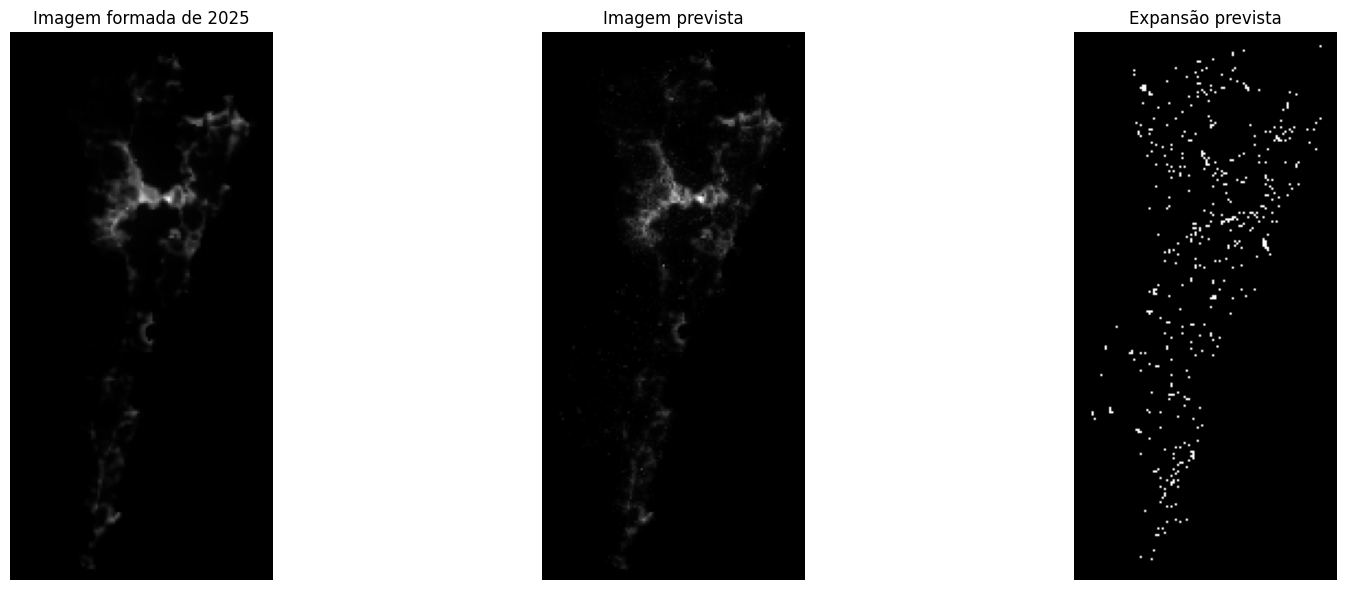

Imagens salvas em:
c:\Users\bielc\OneDrive\Documentos\trabalhos\2026_1\processamento de imagens\processamento-de-imagens-luzes-noturnas\src\generated_images


In [145]:
regiao = "FLORIANOPOLIS"

pred_img, img_final, crescimento_previsto = gerar_expansao(regiao)

visualizar_expansao(pred_img, img_final, crescimento_previsto)
salvar_resultados(pred_img, crescimento_previsto)